# System Setup

## Imports and Installs

### Installs

In [54]:
!pip install geopandas
!pip install geojson
!pip install overpass
!pip install alphashape

Simulation progress:   0%|          | 0/3600 [12:16<?, ?it/s]


### Imports

In [55]:
import pandas as pd
import json
import geojson
#https://github.com/mvexel/overpass-api-python-wrapper/blob/main/README.md
import overpass
#https://pypi.org/project/osm2geojson/
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
from google.colab import drive
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

In [56]:
import numpy as np
import pickle
import random
import json
from itertools import permutations
import time as time_module
import networkx as nx
from datetime import datetime

## Parameters

In [57]:
state_name = "Ohio"
city_name = "Columbus"
mini = True

## Connecting to Drive

We first mount the drive. This step requires permission to be given. Running the cell should open a permission page to allow colab access to google drive.

In [58]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Setting the file directory to the data folder. All files will be referenced to this working directory.

Folder structure:

```
📁Drive/
└─ 📁<personal_dir>/
   ├─ 📁<city_name_1> - RL Delivery Data/
   ├─ 📁<city_name_2> - RL Delivery Data/
   └─ 📁Raw GeoJsons/
```


## Assign Data directory path

In [59]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"
output_dir = data_dir + "/UMST Graph/bundling"


In [60]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Output directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/bundling
Files in directory :  ['Census Data', 'Images', 'Hotspot Data', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'UMST Graph', 'gh_cache']


## Load Data

#### Loading city data

In [61]:
# === FILE PATHS ===
umst_path = data_dir + "/UMST Graph/graphs/umst_graph.graphml"
mst_path = data_dir + "/UMST Graph/graphs/mst_graph.graphml"
hotspot_path = data_dir + "/UMST Graph/graphs/gh_hotspot_graph.graphml"
census_path = data_dir + "/Census Data/census_tract_data.geojson"
hotspot_geojson_path = data_dir + "/Hotspot Data/hotspot_data.geojson"

# === 1. LOAD GRAPHS ===
print("\n[1] Loading graphs from files...")
print(f"    UMST path: {umst_path}")
print(f"    MST path: {mst_path}")
print(f"    Hotspot path: {hotspot_path}")
print(f"    Census path: {census_path}")

umst_graph = nx.read_graphml(umst_path)
mst_graph = nx.read_graphml(mst_path)
hotspot_graph = nx.read_graphml(hotspot_path)

# Load census tract boundaries for visualization
try:
    census_gdf = gpd.read_file(census_path, crs='EPSG:4326')
    print(f"    ✓ Census tracts loaded: {len(census_gdf)} tracts")
except Exception as e:
    print(f"    ⚠ Warning: Could not load census data: {e}")
    print(f"    Continuing without census tract boundaries...")
    census_gdf = None

print(f"    ✓ Hotspot Graph: {hotspot_graph.number_of_nodes()} nodes, {hotspot_graph.number_of_edges()} edges")
print(f"    ✓ MST Graph: {mst_graph.number_of_nodes()} nodes, {mst_graph.number_of_edges()} edges")
print(f"    ✓ UMST Graph: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")


# Get number of hotspots (nodes)
num_hotspots = umst_graph.number_of_nodes()
print(f"Number of hotspots: {num_hotspots}")


[1] Loading graphs from files...
    UMST path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/umst_graph.graphml
    MST path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/mst_graph.graphml
    Hotspot path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/gh_hotspot_graph.graphml
    Census path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Census Data/census_tract_data.geojson
    ✓ Census tracts loaded: 26 tracts
    ✓ Hotspot Graph: 26 nodes, 325 edges
    ✓ MST Graph: 26 nodes, 25 edges
    ✓ UMST Graph: 26 nodes, 47 edges
Number of hotspots: 26


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


In [62]:
# print("Graph edges with attributes:")
# for u, v, data in umst_graph.edges(data=True):
#     print(f"{u} -- {v} | distance={data.get('distance')} | time={data.get('time')}")


# Deliveries

In [63]:
"""
Complete Dynamic Food Delivery Bundling System
Integrates with your existing UMST graph setup
"""

import numpy as np
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque
from tqdm import tqdm
import heapq
from dataclasses import dataclass
from enum import Enum
import sys
import pickle
import json
from datetime import datetime
import random

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """System configuration"""
    # Simulation
    SIMULATION_HOURS = 1
    SERVICE_TIME_SECONDS = 30

    # Bundling
    MAX_BUNDLE_SIZE = 5
    TIME_WINDOW_SECONDS = 300  # 5 minutes
    REPLAN_INTERVAL = 60  # Re-optimize every minute
    MAX_VEHICLES = 50

    # Distance/Time
    TIME_LIMIT_MULTIPLIER = 1.5
    TIME_INTERVALS = [300, 600, 900, 1200, 1800, 2400, 3000, 3600]
    MAX_GEOGRAPHIC_DISTANCE_RATIO = 0.4
    LARGE_NUMBER = 1e9

    # Delivery generation
    PEAK_TIMES = [0.25, 0.75]  # Peak at 15min and 45min
    PEAK_SIGMA = 10

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def is_valid_path(dist_matrix, start_idx, end_idx, threshold=None):
    """Check if path exists and is valid"""
    if threshold is None:
        threshold = Config.LARGE_NUMBER
    value = dist_matrix[start_idx, end_idx]
    return value < threshold and value != sys.maxsize

def get_valid_distance(dist_matrix, start_idx, end_idx):
    """Get distance if valid, None otherwise"""
    if is_valid_path(dist_matrix, start_idx, end_idx):
        return dist_matrix[start_idx, end_idx]
    return None

def get_valid_time(time_matrix, start_idx, end_idx):
    """Get time if valid, None otherwise"""
    if is_valid_path(time_matrix, start_idx, end_idx):
        return time_matrix[start_idx, end_idx]
    return None

# ============================================================================
# MATRIX CREATION
# ============================================================================

def create_distance_time_matrices(graph):
    """Create distance and time matrices from graph"""
    print("\n[2] Creating distance and time matrices...")

    nodes = list(graph.nodes())
    n = len(nodes)

    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    idx_to_node = {idx: node for idx, node in enumerate(nodes)}

    dist_matrix = np.full((n, n), Config.LARGE_NUMBER, dtype=float)
    time_matrix = np.full((n, n), Config.LARGE_NUMBER, dtype=float)

    np.fill_diagonal(dist_matrix, 0)
    np.fill_diagonal(time_matrix, 0)

    print("   Computing shortest paths...")

    for source_node in tqdm(nodes, desc="   Processing nodes"):
        source_idx = node_to_idx[source_node]

        try:
            lengths_dist = nx.single_source_dijkstra_path_length(
                graph, source_node, weight='distance'
            )
            lengths_time = nx.single_source_dijkstra_path_length(
                graph, source_node, weight='time'
            )

            for target_node, distance in lengths_dist.items():
                target_idx = node_to_idx[target_node]
                dist_matrix[source_idx, target_idx] = distance * 1000

            for target_node, time in lengths_time.items():
                target_idx = node_to_idx[target_node]
                time_matrix[source_idx, target_idx] = time * 60

        except nx.NetworkXNoPath:
            pass

    valid_distances = dist_matrix[dist_matrix < Config.LARGE_NUMBER]
    valid_times = time_matrix[time_matrix < Config.LARGE_NUMBER]

    print(f"   ✓ Distance matrix shape: {dist_matrix.shape}")
    print(f"   ✓ Time matrix shape: {time_matrix.shape}")
    print(f"   ✓ Valid paths: {len(valid_distances)} / {n*n}")
    print(f"   ✓ Max distance: {np.max(valid_distances):.2f} meters")
    print(f"   ✓ Max time: {np.max(valid_times):.2f} seconds")

    return dist_matrix, time_matrix, node_to_idx, idx_to_node

In [64]:

# ============================================================================
# DELIVERY BUNDLE
# ============================================================================

class DeliveryBundle:
    """Bundle with pickup-before-delivery constraints"""
    bundle_id_counter = 0

    def __init__(self, max_capacity=5):
        self.bundle_id = DeliveryBundle.bundle_id_counter
        DeliveryBundle.bundle_id_counter += 1

        self.max_capacity = max_capacity
        self.deliveries = []
        self.route = []
        self.route_times = []
        self.total_distance = 0
        self.total_time = 0
        self.start_time = None
        self.end_time = None
        self.zone_id = None

    def can_add_delivery(self, delivery, time_window, dist_matrix, umst_analyzer=None):
        """Check if delivery can be added"""
        if len(self.deliveries) >= self.max_capacity:
            return False

        if self.start_time is not None:
            if abs(delivery.start_time - self.start_time) > time_window:
                return False

        if len(self.deliveries) == 0:
            if umst_analyzer:
                self.zone_id = umst_analyzer.get_zone(delivery.start_node_idx)
            return True

        # Zone compatibility
        if umst_analyzer:
            delivery_zone = umst_analyzer.get_zone(delivery.start_node_idx)
            if self.zone_id != delivery_zone:
                if not umst_analyzer.are_adjacent_zones(delivery.start_node_idx,
                                                       self.deliveries[0].start_node_idx):
                    return False

        # Geographic proximity
        if dist_matrix is not None:
            valid_distances = []
            for d in self.deliveries:
                dist = get_valid_distance(dist_matrix, delivery.end_node_idx, d.end_node_idx)
                if dist is not None:
                    valid_distances.append(dist)

            if not valid_distances:
                return False

            avg_distance = np.mean(valid_distances)
            valid_dists = dist_matrix[dist_matrix < Config.LARGE_NUMBER]
            max_dist = np.max(valid_dists) if len(valid_dists) > 0 else 1.0

            if avg_distance > Config.MAX_GEOGRAPHIC_DISTANCE_RATIO * max_dist:
                return False

        return True

    def add_delivery(self, delivery):
        """Add delivery to bundle"""
        if len(self.deliveries) < self.max_capacity:
            self.deliveries.append(delivery)
            delivery.bundled = True
            delivery.bundle_id = self.bundle_id

            if self.start_time is None:
                self.start_time = delivery.start_time
            else:
                self.start_time = min(self.start_time, delivery.start_time)

            return True
        return False

    def optimize_route_with_constraints(self, dist_matrix, time_matrix):
        """Optimize with pickup-before-delivery constraint"""
        if len(self.deliveries) == 0:
            return

        if len(self.deliveries) <= 3:
            self._optimize_small(dist_matrix, time_matrix)
        else:
            self._optimize_greedy(dist_matrix, time_matrix)

    def _optimize_small(self, dist_matrix, time_matrix):
        """Exact optimization for small bundles"""
        # Simple heuristic: pickup all, then deliver by nearest neighbor
        route = []

        # All pickups first
        for idx, delivery in enumerate(self.deliveries):
            route.append(('pickup', idx, delivery.start_node_idx))

        # Deliveries by nearest neighbor
        if self.deliveries:
            current_node = self.deliveries[-1].start_node_idx
            remaining = set(range(len(self.deliveries)))

            while remaining:
                best_idx = None
                best_dist = float('inf')

                for idx in remaining:
                    delivery = self.deliveries[idx]
                    dist = get_valid_distance(dist_matrix, current_node, delivery.end_node_idx)

                    if dist is not None and dist < best_dist:
                        best_dist = dist
                        best_idx = idx

                if best_idx is not None:
                    delivery = self.deliveries[best_idx]
                    route.append(('delivery', best_idx, delivery.end_node_idx))
                    current_node = delivery.end_node_idx
                    remaining.remove(best_idx)
                else:
                    break

        self.route = route
        self._finalize_metrics(dist_matrix, time_matrix)

    def _optimize_greedy(self, dist_matrix, time_matrix):
        """Greedy for larger bundles"""
        self._optimize_small(dist_matrix, time_matrix)

    def _finalize_metrics(self, dist_matrix, time_matrix):
        """Calculate final metrics"""
        if not self.route:
            return

        self.total_distance = 0
        self.total_time = 0

        for i in range(len(self.route) - 1):
            current = self.route[i][2]
            next_stop = self.route[i+1][2]

            dist = get_valid_distance(dist_matrix, current, next_stop)
            time = get_valid_time(time_matrix, current, next_stop)

            if dist: self.total_distance += dist
            if time: self.total_time += time

        # Calculate arrival times
        self.route_times = [self.start_time]
        current_time = self.start_time

        for i in range(len(self.route) - 1):
            current = self.route[i][2]
            next_stop = self.route[i+1][2]

            travel_time = get_valid_time(time_matrix, current, next_stop)
            if travel_time:
                current_time += travel_time + Config.SERVICE_TIME_SECONDS

            self.route_times.append(current_time)

        self.end_time = current_time

        # Assign times to deliveries
        for i, (action_type, delivery_idx, node) in enumerate(self.route):
            delivery = self.deliveries[delivery_idx]

            if action_type == 'pickup':
                delivery.pickup_time = self.route_times[i]
            elif action_type == 'delivery':
                delivery.delivery_time = self.route_times[i]
                delivery.total_travel_time = delivery.delivery_time - delivery.start_time
                delivery.waiting_time = delivery.pickup_time - delivery.start_time if delivery.pickup_time else 0
                delivery.successful = (delivery.total_travel_time <= delivery.time_limit)


In [65]:
# ============================================================================
# UMST ANALYZER
# ============================================================================

class UMSTAnalyzer:
    """Analyzes UMST structure to identify service zones"""

    def __init__(self, graph):
        self.graph = graph
        self.subtrees = None
        self.hub_nodes = None
        self.node_to_zone = {}

    def identify_zones(self, method='degree_based', hub_threshold=4):
        """Identify service zones in UMST"""
        print(f"\n[3] Analyzing UMST Structure: {method}")

        degrees = dict(self.graph.degree())
        self.hub_nodes = [n for n, d in degrees.items() if d >= hub_threshold]

        print(f"  Found {len(self.hub_nodes)} hub nodes (degree >= {hub_threshold})")

        zones = defaultdict(list)

        for node in self.graph.nodes():
            if node in self.hub_nodes:
                zones[node].append(node)
                self.node_to_zone[node] = node
            else:
                min_dist = float('inf')
                closest_hub = None

                for hub in self.hub_nodes:
                    try:
                        dist = nx.shortest_path_length(self.graph, node, hub, weight='distance')
                        if dist < min_dist:
                            min_dist = dist
                            closest_hub = hub
                    except nx.NetworkXNoPath:
                        continue

                if closest_hub:
                    zones[closest_hub].append(node)
                    self.node_to_zone[node] = closest_hub
                else:
                    zones[node].append(node)
                    self.node_to_zone[node] = node

        self.subtrees = dict(zones)
        print(f"  Created {len(self.subtrees)} zones")

        zone_sizes = [len(nodes) for nodes in self.subtrees.values()]
        print(f"  Zone sizes: min={min(zone_sizes)}, max={max(zone_sizes)}, avg={np.mean(zone_sizes):.1f}")

        return self.subtrees

    def get_zone(self, node_idx):
        """Get zone ID for a node"""
        return self.node_to_zone.get(node_idx, None)

    def are_adjacent_zones(self, node1_idx, node2_idx):
        """Check if two nodes are in adjacent zones"""
        zone1 = self.get_zone(node1_idx)
        zone2 = self.get_zone(node2_idx)

        if zone1 == zone2:
            return True

        if zone1 in self.subtrees and zone2 in self.subtrees:
            for n1 in self.subtrees[zone1]:
                for n2 in self.graph.neighbors(n1):
                    if self.get_zone(n2) == zone2:
                        return True

        return False


In [66]:

# ============================================================================
# DELIVERY CLASS
# ============================================================================

class Delivery:
    """Represents a single food delivery order"""
    id_counter = 0

    def __init__(self, start_node_idx, end_node_idx, start_time, time_matrix):
        self.id = Delivery.id_counter
        Delivery.id_counter += 1

        self.start_node_idx = start_node_idx
        self.end_node_idx = end_node_idx
        self.start_time = start_time
        self.time_limit = self._calculate_time_limit(time_matrix)

        self.bundle_id = None
        self.pickup_time = None
        self.delivery_time = None
        self.total_travel_time = None
        self.waiting_time = None

        self.bundled = False
        self.completed = False
        self.successful = False
        self.status = "pending"

    def _calculate_time_limit(self, time_matrix):
        """Calculate delivery deadline"""
        direct_time = get_valid_time(time_matrix, self.start_node_idx, self.end_node_idx)

        if direct_time is None:
            return float('inf')

        target_time = direct_time * Config.TIME_LIMIT_MULTIPLIER

        for interval in Config.TIME_INTERVALS:
            if target_time <= interval:
                return interval

        return Config.TIME_INTERVALS[-1]

    def is_valid(self, time_matrix):
        """Check if delivery has valid path"""
        return is_valid_path(time_matrix, self.start_node_idx, self.end_node_idx)

In [67]:
# ============================================================================
# DELIVERY GENERATION
# ============================================================================

def generate_deliveries(num_deliveries, num_hotspots, time_matrix, hours=1,
                       peaks=None, sigma=10, distance_based="closer"):
    """Generate food delivery orders with realistic temporal distribution"""
    if peaks is None:
        peaks = Config.PEAK_TIMES

    print(f"\n[4] Generating {num_deliveries} food delivery orders...")

    # Temporal distribution (lunch/dinner peaks)
    mu_list = [peak * 60 * hours for peak in peaks]
    x = np.linspace(0, 60 * hours, 60 * hours)

    y_combined = np.zeros_like(x)
    for mu in mu_list:
        y_combined += (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    loads = [int((num_deliveries / sum(y_combined)) * y) for y in y_combined]

    while sum(loads) < num_deliveries:
        loads[random.randint(0, len(loads)-1)] += 1
    while sum(loads) > num_deliveries:
        idx = random.randint(0, len(loads)-1)
        if loads[idx] > 0:
            loads[idx] -= 1

    # Generate deliveries
    deliveries = []
    valid_nodes = list(range(num_hotspots))
    valid_distances = time_matrix[time_matrix < Config.LARGE_NUMBER]
    max_dist = np.max(valid_distances) if len(valid_distances) > 0 else 1.0

    with tqdm(total=sum(loads), desc="   Creating orders") as pbar:
        for minute_idx in range(len(loads)):
            for _ in range(loads[minute_idx]):
                attempts = 0
                max_attempts = 100

                while attempts < max_attempts:
                    attempts += 1
                    start_idx = random.choice(valid_nodes)
                    end_idx = random.choice(valid_nodes)

                    if not is_valid_path(time_matrix, start_idx, end_idx):
                        continue
                    if start_idx == end_idx:
                        continue

                    if distance_based == "closer":
                        dist = time_matrix[start_idx, end_idx]
                        dist_ratio = dist / max_dist
                        if dist_ratio > 0.5:
                            continue

                    break

                if attempts >= max_attempts:
                    continue

                time_seconds = minute_idx * 60 + random.randint(0, 59)
                delivery = Delivery(start_idx, end_idx, time_seconds, time_matrix)

                if delivery.is_valid(time_matrix):
                    deliveries.append(delivery)
                    pbar.update(1)

    print(f"   ✓ Generated {len(deliveries)} valid orders")
    return deliveries

In [68]:
# ============================================================================
# DYNAMIC BUNDLING ENGINE
# ============================================================================
from itertools import count

class DynamicBundlingEngine:
    """Real-time food delivery bundling engine"""

    def __init__(self, umst_graph, dist_matrix, time_matrix, node_to_idx, idx_to_node,
                 max_bundle_size=5, time_window=300, replan_interval=60,
                 max_vehicles=50, umst_analyzer=None):

        self.umst_graph = umst_graph
        self.dist_matrix = dist_matrix
        self.time_matrix = time_matrix
        self.node_to_idx = node_to_idx
        self.idx_to_node = idx_to_node
        self.umst_analyzer = umst_analyzer

        self.max_bundle_size = max_bundle_size
        self.time_window = time_window
        self.replan_interval = replan_interval
        self.max_vehicles = max_vehicles

        self.current_time = 0
        self.vehicles = {}
        self.pending_orders = []
        self.active_bundles = {}
        self.completed_deliveries = []
        self.failed_deliveries = []

        self.event_queue = []
        self.counter = count()

        self.metrics = {
            'orders_received': 0,
            'orders_assigned': 0,
            'orders_delivered': 0,
            'orders_failed': 0,
            'vehicles_used': 0,
            'total_distance': 0,
            'total_time': 0,
            'replan_count': 0,
            'insertion_count': 0
        }

        self.last_replan = 0

    def initialize_vehicles(self, num_vehicles, depot_node=0):
        """Initialize vehicle fleet"""
        print(f"\n[5] Initializing {num_vehicles} vehicles")

        for i in range(num_vehicles):
            self.vehicles[i] = {
                'id': i,
                'status': 'idle',
                'location': depot_node,
                'time': 0,
                'bundle': None,
                'route_idx': 0
            }

        self.metrics['vehicles_used'] = num_vehicles

    def add_order_stream(self, deliveries):
        """Add orders to event queue"""
        print(f"\n[6] Adding {len(deliveries)} orders to stream")

        for delivery in sorted(deliveries, key=lambda d: d.start_time):
            heapq.heappush(self.event_queue, (delivery.start_time, next(self.counter), 'order', delivery))


    def run_simulation(self, simulation_hours=1):
        """Run dynamic simulation"""
        print(f"\n{'='*70}")
        print(f"RUNNING DYNAMIC SIMULATION - {simulation_hours} HOUR(S)")
        print(f"{'='*70}")

        simulation_end = simulation_hours * 3600

        pbar = tqdm(total=simulation_end, desc="Simulation progress")

        while self.event_queue and self.current_time <= simulation_end:
            # Unpack with counter (4 elements now instead of 3)
            event_time, _, event_type, event_data = heapq.heappop(self.event_queue)

            time_delta = event_time - self.current_time
            if time_delta > 0:
                pbar.update(min(time_delta, simulation_end - self.current_time))
            self.current_time = event_time

            if self.current_time > simulation_end:
                break

            if event_type == 'order':
                self._handle_order(event_data)
            elif event_type == 'vehicle_arrival':
                self._handle_vehicle_arrival(event_data)
            elif event_type == 'replan':
                self._handle_replan()

            if self.current_time - self.last_replan >= self.replan_interval:
                # Add counter when pushing to queue
                heapq.heappush(self.event_queue, (self.current_time, next(self.counter), 'replan', None))

        pbar.close()

        # Mark remaining as failed
        for order in self.pending_orders:
            order.status = "failed"
            self.failed_deliveries.append(order)
            self.metrics['orders_failed'] += 1

        return self._get_results()

    def _handle_order(self, delivery):
        """Handle new order arrival"""
        self.metrics['orders_received'] += 1

        # Try immediate insertion
        if self._try_insertion(delivery):
            self.metrics['orders_assigned'] += 1
            self.metrics['insertion_count'] += 1
            delivery.status = "assigned"
        else:
            # Add to pending
            self.pending_orders.append(delivery)

            # Try dispatch new vehicle
            if self._dispatch_vehicle(delivery):
                self.metrics['orders_assigned'] += 1
                delivery.status = "assigned"
                self.pending_orders.remove(delivery)

    def _try_insertion(self, delivery):
        """Try to insert into existing route"""
        for vehicle in self.vehicles.values():
            if vehicle['status'] == 'idle' or vehicle['bundle'] is None:
                continue

            bundle = vehicle['bundle']

            if len(bundle.deliveries) >= self.max_bundle_size:
                continue

            if abs(delivery.start_time - bundle.start_time) > self.time_window:
                continue

            if bundle.can_add_delivery(delivery, self.time_window, self.dist_matrix, self.umst_analyzer):
                bundle.add_delivery(delivery)
                bundle.optimize_route_with_constraints(self.dist_matrix, self.time_matrix)
                return True

        return False

    def _dispatch_vehicle(self, delivery):
        """Dispatch new vehicle"""
        idle_vehicle = None
        for vehicle in self.vehicles.values():
            if vehicle['status'] == 'idle':
                idle_vehicle = vehicle
                break

        if not idle_vehicle:
            return False

        bundle = DeliveryBundle(max_capacity=self.max_bundle_size)
        bundle.add_delivery(delivery)
        bundle.optimize_route_with_constraints(self.dist_matrix, self.time_matrix)

        idle_vehicle['bundle'] = bundle
        idle_vehicle['status'] = 'active'
        idle_vehicle['route_idx'] = 0

        self.active_bundles[bundle.bundle_id] = bundle

        self._schedule_vehicle(idle_vehicle)

        return True

    def _schedule_vehicle(self, vehicle):
        """Schedule vehicle route events"""
        bundle = vehicle['bundle']
        if not bundle.route:
            return

        current_time = self.current_time
        current_loc = vehicle['location']

        for i, (action, idx, node) in enumerate(bundle.route):
            travel_time = get_valid_time(self.time_matrix, current_loc, node)

            if travel_time:
                current_time += travel_time + Config.SERVICE_TIME_SECONDS

                heapq.heappush(self.event_queue,
                             (current_time, next(self.counter), 'vehicle_arrival',
                              {'vehicle_id': vehicle['id'],
                               'location': node,
                               'action': action,
                               'delivery_idx': idx}))

                current_loc = node

    def _handle_vehicle_arrival(self, data):
        """Handle vehicle arrival at location"""
        vehicle = self.vehicles[data['vehicle_id']]
        vehicle['location'] = data['location']
        vehicle['time'] = self.current_time

        bundle = vehicle['bundle']
        if not bundle:
            return

        action = data['action']
        idx = data['delivery_idx']
        delivery = bundle.deliveries[idx]

        if action == 'pickup':
            delivery.pickup_time = self.current_time
            delivery.status = "in_transit"

        elif action == 'delivery':
            delivery.delivery_time = self.current_time
            delivery.total_travel_time = delivery.delivery_time - delivery.start_time

            if delivery.total_travel_time <= delivery.time_limit:
                delivery.status = "delivered"
                delivery.successful = True
                self.completed_deliveries.append(delivery)
                self.metrics['orders_delivered'] += 1
            else:
                delivery.status = "failed"
                delivery.successful = False
                self.failed_deliveries.append(delivery)
                self.metrics['orders_failed'] += 1

        vehicle['route_idx'] += 1
        if vehicle['route_idx'] >= len(bundle.route):
            vehicle['status'] = 'idle'
            vehicle['bundle'] = None
            vehicle['route_idx'] = 0

            self.metrics['total_distance'] += bundle.total_distance
            self.metrics['total_time'] += bundle.total_time

    def _handle_replan(self):
        """Rolling-horizon replanning"""
        self.metrics['replan_count'] += 1
        self.last_replan = self.current_time

        if not self.pending_orders:
            return

        # Filter viable orders
        viable = []
        for order in self.pending_orders:
            time_left = order.time_limit - (self.current_time - order.start_time)
            if time_left > 60:
                viable.append(order)
            else:
                order.status = "failed"
                self.failed_deliveries.append(order)
                self.metrics['orders_failed'] += 1

        self.pending_orders = viable

        if not self.pending_orders:
            return

        # Bundle pending orders
        bundles = self._bundle_pending()

        # Dispatch vehicles
        for bundle in bundles:
            idle_vehicle = None
            for vehicle in self.vehicles.values():
                if vehicle['status'] == 'idle':
                    idle_vehicle = vehicle
                    break

            if idle_vehicle:
                idle_vehicle['bundle'] = bundle
                idle_vehicle['status'] = 'active'
                idle_vehicle['route_idx'] = 0

                self.active_bundles[bundle.bundle_id] = bundle

                for delivery in bundle.deliveries:
                    delivery.status = "assigned"
                    self.metrics['orders_assigned'] += 1
                    if delivery in self.pending_orders:
                        self.pending_orders.remove(delivery)

                self._schedule_vehicle(idle_vehicle)

    def _bundle_pending(self):
        """Bundle pending orders by zone"""
        zone_orders = defaultdict(list)

        for order in self.pending_orders:
            zone = self.umst_analyzer.get_zone(order.start_node_idx) if self.umst_analyzer else 0
            zone_orders[zone].append(order)

        bundles = []

        for zone_id, orders in zone_orders.items():
            orders.sort(key=lambda d: d.start_time)

            for i in range(0, len(orders), self.max_bundle_size):
                bundle = DeliveryBundle(max_capacity=self.max_bundle_size)
                bundle.zone_id = zone_id

                for order in orders[i:i+self.max_bundle_size]:
                    bundle.add_delivery(order)

                bundle.optimize_route_with_constraints(self.dist_matrix, self.time_matrix)
                bundles.append(bundle)

        return bundles

    def _get_results(self):
        """Get simulation results"""
        total = self.metrics['orders_received']

        return {
            'total_orders': total,
            'delivered': self.metrics['orders_delivered'],
            'failed': self.metrics['orders_failed'],
            'success_rate': self.metrics['orders_delivered'] / total if total > 0 else 0,
            'vehicles_used': self.metrics['vehicles_used'],
            'total_distance_km': self.metrics['total_distance'] / 1000,
            'total_time_hours': self.metrics['total_time'] / 3600,
            'replan_count': self.metrics['replan_count'],
            'insertions': self.metrics['insertion_count'],
            'avg_per_vehicle': self.metrics['orders_delivered'] / self.metrics['vehicles_used'] if self.metrics['vehicles_used'] > 0 else 0
        }

    def print_results(self):
        """Print comprehensive results"""
        results = self._get_results()

        print(f"\n{'='*70}")
        print(f"DYNAMIC BUNDLING RESULTS")
        print(f"{'='*70}")

        print(f"\n📦 ORDERS:")
        print(f"    Total received:     {results['total_orders']}")
        print(f"    Delivered:          {results['delivered']} ({results['success_rate']*100:.1f}%)")
        print(f"    Failed:             {results['failed']}")

        print(f"\n🚗 VEHICLES:")
        print(f"    Vehicles used:      {results['vehicles_used']}")
        print(f"    Avg orders/vehicle: {results['avg_per_vehicle']:.2f}")

        print(f"\n📊 EFFICIENCY:")
        print(f"    Total distance:     {results['total_distance_km']:.2f} km")
        print(f"    Total time:         {results['total_time_hours']:.2f} hours")

        print(f"\n🔄 DYNAMICS:")
        print(f"    Replanning events:  {results['replan_count']}")
        print(f"    Dynamic insertions: {results['insertions']}")

        print(f"{'='*70}\n")

        return results

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_dynamic_results(engine, save_path='dynamic_results.png'):
    """Create comprehensive visualization"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Dynamic Food Delivery Bundling - Real-Time Results',
                 fontsize=16, fontweight='bold')

    # 1. Order status timeline
    ax = axes[0, 0]
    all_deliveries = engine.completed_deliveries + engine.failed_deliveries

    if all_deliveries:
        arrival_times = [d.start_time / 60 for d in all_deliveries]
        delivery_times = [d.delivery_time / 60 if d.delivery_time else 0 for d in all_deliveries]
        colors = ['green' if d.successful else 'red' for d in all_deliveries]

        ax.scatter(arrival_times, delivery_times, c=colors, alpha=0.5, s=20)
        ax.set_xlabel('Order Arrival Time (min)')
        ax.set_ylabel('Delivery Completion Time (min)')
        ax.set_title('Order Timeline (Green=Success, Red=Failed)')
        ax.grid(alpha=0.3)

    # 2. Success rate over time
    ax = axes[0, 1]
    if all_deliveries:
        window = 300  # 5 minute windows
        max_time = max([d.start_time for d in all_deliveries])
        time_bins = np.arange(0, max_time + window, window)

        success_rates = []
        bin_centers = []

        for i in range(len(time_bins) - 1):
            orders_in_bin = [d for d in all_deliveries
                           if time_bins[i] <= d.start_time < time_bins[i+1]]
            if orders_in_bin:
                success = sum(1 for d in orders_in_bin if d.successful)
                success_rates.append(success / len(orders_in_bin) * 100)
                bin_centers.append((time_bins[i] + time_bins[i+1]) / 2 / 60)

        ax.plot(bin_centers, success_rates, marker='o', linewidth=2)
        ax.set_xlabel('Time (minutes)')
        ax.set_ylabel('Success Rate (%)')
        ax.set_title('Success Rate Over Time (5-min windows)')
        ax.set_ylim([0, 105])
        ax.grid(alpha=0.3)
        ax.axhline(y=np.mean(success_rates) if success_rates else 0,
                   color='r', linestyle='--', label=f'Avg: {np.mean(success_rates):.1f}%')
        ax.legend()

    # 3. Bundle size distribution
    ax = axes[0, 2]
    bundle_sizes = [len(b.deliveries) for b in engine.active_bundles.values()]

    if bundle_sizes:
        ax.hist(bundle_sizes, bins=range(1, max(bundle_sizes)+2),
                edgecolor='black', alpha=0.7, color='skyblue')
        ax.set_xlabel('Bundle Size (orders)')
        ax.set_ylabel('Frequency')
        ax.set_title('Bundle Size Distribution')
        ax.axvline(np.mean(bundle_sizes), color='red', linestyle='--',
                   label=f'Avg: {np.mean(bundle_sizes):.2f}')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    # 4. Vehicle utilization
    ax = axes[1, 0]
    vehicle_orders = defaultdict(int)

    for delivery in engine.completed_deliveries:
        if delivery.bundle_id is not None:
            # Find which vehicle handled this
            for vehicle in engine.vehicles.values():
                if vehicle['bundle'] and vehicle['bundle'].bundle_id == delivery.bundle_id:
                    vehicle_orders[vehicle['id']] += 1
                    break

    if vehicle_orders:
        vehicles = list(vehicle_orders.keys())
        orders = [vehicle_orders[v] for v in vehicles]

        ax.bar(vehicles, orders, color='orange', alpha=0.7)
        ax.set_xlabel('Vehicle ID')
        ax.set_ylabel('Orders Delivered')
        ax.set_title('Vehicle Utilization')
        ax.grid(axis='y', alpha=0.3)

    # 5. Delivery time vs time limit
    ax = axes[1, 1]
    successful = [d for d in all_deliveries if d.successful and d.total_travel_time]

    if successful:
        actual_times = [d.total_travel_time / 60 for d in successful]
        time_limits = [d.time_limit / 60 for d in successful]

        ax.scatter(time_limits, actual_times, alpha=0.5, s=20, color='green')

        # Diagonal line
        max_val = max(max(time_limits), max(actual_times))
        ax.plot([0, max_val], [0, max_val], 'r--', label='Time Limit')

        ax.set_xlabel('Time Limit (min)')
        ax.set_ylabel('Actual Delivery Time (min)')
        ax.set_title('Delivery Time vs Time Limit')
        ax.legend()
        ax.grid(alpha=0.3)

    # 6. Waiting time distribution
    ax = axes[1, 2]
    waiting_times = [d.waiting_time / 60 for d in engine.completed_deliveries
                     if d.waiting_time is not None and d.waiting_time >= 0]

    if waiting_times:
        ax.hist(waiting_times, bins=30, edgecolor='black', alpha=0.7, color='coral')
        ax.set_xlabel('Waiting Time (min)')
        ax.set_ylabel('Frequency')
        ax.set_title('Order Waiting Time Distribution')
        ax.axvline(np.mean(waiting_times), color='red', linestyle='--',
                   label=f'Avg: {np.mean(waiting_times):.1f} min')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Visualization saved: {save_path}")

    return fig

def plot_zone_analysis(umst_analyzer, engine, save_path='zone_analysis.png'):
    """Analyze performance by zone"""

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('UMST Zone Analysis', fontsize=14, fontweight='bold')

    # Orders per zone
    ax = axes[0]
    zone_orders = defaultdict(int)

    all_deliveries = engine.completed_deliveries + engine.failed_deliveries
    for delivery in all_deliveries:
        zone = umst_analyzer.get_zone(delivery.start_node_idx)
        if zone is not None:
            zone_orders[zone] += 1

    if zone_orders:
        zones = list(zone_orders.keys())
        counts = [zone_orders[z] for z in zones]

        ax.bar(range(len(zones)), counts, color='steelblue', alpha=0.7)
        ax.set_xlabel('Zone ID')
        ax.set_ylabel('Number of Orders')
        ax.set_title('Orders per UMST Zone')
        ax.grid(axis='y', alpha=0.3)

    # Success rate per zone
    ax = axes[1]
    zone_success = defaultdict(lambda: {'total': 0, 'success': 0})

    for delivery in all_deliveries:
        zone = umst_analyzer.get_zone(delivery.start_node_idx)
        if zone is not None:
            zone_success[zone]['total'] += 1
            if delivery.successful:
                zone_success[zone]['success'] += 1

    if zone_success:
        zones = list(zone_success.keys())
        success_rates = [zone_success[z]['success'] / zone_success[z]['total'] * 100
                        for z in zones]

        colors = ['green' if sr >= 80 else 'orange' if sr >= 60 else 'red'
                 for sr in success_rates]

        ax.bar(range(len(zones)), success_rates, color=colors, alpha=0.7)
        ax.set_xlabel('Zone ID')
        ax.set_ylabel('Success Rate (%)')
        ax.set_title('Success Rate by UMST Zone')
        ax.set_ylim([0, 105])
        ax.axhline(y=np.mean(success_rates), color='black', linestyle='--',
                   label=f'Overall: {np.mean(success_rates):.1f}%')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Zone analysis saved: {save_path}")

    return fig

# ============================================================================
# SAVE/LOAD FUNCTIONS
# ============================================================================

def save_simulation_results(engine, umst_analyzer, filename='dynamic_simulation.pkl'):
    """Save complete simulation state"""
    data = {
        'results': engine._get_results(),
        'completed_deliveries': engine.completed_deliveries,
        'failed_deliveries': engine.failed_deliveries,
        'active_bundles': list(engine.active_bundles.values()),
        'zones': umst_analyzer.subtrees,
        'metrics': engine.metrics,
        'timestamp': datetime.now().isoformat()
    }

    with open(filename, 'wb') as f:
        pickle.dump(data, f)

    print(f"✓ Simulation saved: {filename}")

def save_results_json(engine, filename='dynamic_results.json'):
    """Save results as JSON"""
    results = engine._get_results()

    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

    print(f"✓ Results JSON saved: {filename}")

def create_summary_report(engine, umst_analyzer, filename='dynamic_summary.txt'):
    """Create human-readable summary"""
    results = engine._get_results()

    with open(filename, 'w') as f:
        f.write("="*70 + "\n")
        f.write("DYNAMIC FOOD DELIVERY SIMULATION - SUMMARY REPORT\n")
        f.write("="*70 + "\n\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        f.write("CONFIGURATION:\n")
        f.write(f"  Max Bundle Size:    {Config.MAX_BUNDLE_SIZE}\n")
        f.write(f"  Time Window:        {Config.TIME_WINDOW_SECONDS}s ({Config.TIME_WINDOW_SECONDS/60:.1f} min)\n")
        f.write(f"  Replan Interval:    {Config.REPLAN_INTERVAL}s\n")
        f.write(f"  Max Vehicles:       {Config.MAX_VEHICLES}\n\n")

        f.write("UMST STRUCTURE:\n")
        f.write(f"  Total Zones:        {len(umst_analyzer.subtrees)}\n")
        f.write(f"  Hub Nodes:          {len(umst_analyzer.hub_nodes) if umst_analyzer.hub_nodes else 0}\n\n")

        f.write("PERFORMANCE METRICS:\n")
        f.write(f"  Total Orders:       {results['total_orders']}\n")
        f.write(f"  Delivered:          {results['delivered']} ({results['success_rate']*100:.1f}%)\n")
        f.write(f"  Failed:             {results['failed']}\n")
        f.write(f"  Vehicles Used:      {results['vehicles_used']}\n")
        f.write(f"  Avg Orders/Vehicle: {results['avg_per_vehicle']:.2f}\n")
        f.write(f"  Total Distance:     {results['total_distance_km']:.2f} km\n")
        f.write(f"  Total Time:         {results['total_time_hours']:.2f} hours\n\n")

        f.write("DYNAMIC OPERATIONS:\n")
        f.write(f"  Replan Events:      {results['replan_count']}\n")
        f.write(f"  Dynamic Insertions: {results['insertions']}\n\n")

        # Performance by zone
        f.write("ZONE PERFORMANCE:\n")
        zone_stats = defaultdict(lambda: {'total': 0, 'success': 0})

        all_deliveries = engine.completed_deliveries + engine.failed_deliveries
        for d in all_deliveries:
            zone = umst_analyzer.get_zone(d.start_node_idx)
            if zone is not None:
                zone_stats[zone]['total'] += 1
                if d.successful:
                    zone_stats[zone]['success'] += 1

        for zone in sorted(zone_stats.keys()):
            stats = zone_stats[zone]
            success_rate = stats['success'] / stats['total'] * 100 if stats['total'] > 0 else 0
            f.write(f"  Zone {zone}: {stats['success']}/{stats['total']} ({success_rate:.1f}%)\n")

        f.write("\n" + "="*70 + "\n")

    print(f"✓ Summary report saved: {filename}")

# ============================================================================
# MAIN EXECUTION FUNCTION
# ============================================================================

def run_complete_dynamic_simulation(umst_graph, num_deliveries=3000,
                                   max_bundle_size=5, time_window=300,
                                   simulation_hours=1, replan_interval=60,
                                   max_vehicles=50, distance_based="closer",
                                   save_files=True):
    """
    Complete dynamic food delivery simulation

    This is the MAIN FUNCTION to call after loading your graphs
    """

    print("\n" + "="*70)
    print("🍔 DYNAMIC FOOD DELIVERY BUNDLING SYSTEM")
    print("="*70)
    print(f"\nConfiguration:")
    print(f"  Orders:             {num_deliveries}")
    print(f"  Max Bundle Size:    {max_bundle_size}")
    print(f"  Time Window:        {time_window}s ({time_window/60:.1f} min)")
    print(f"  Simulation:         {simulation_hours} hour(s)")
    print(f"  Replan Interval:    {replan_interval}s")
    print(f"  Max Vehicles:       {max_vehicles}")
    print(f"  Distance Strategy:  {distance_based}")
    print("="*70)

    # Reset counters
    Delivery.id_counter = 0
    DeliveryBundle.bundle_id_counter = 0

    # Update config
    Config.MAX_BUNDLE_SIZE = max_bundle_size
    Config.TIME_WINDOW_SECONDS = time_window
    Config.REPLAN_INTERVAL = replan_interval
    Config.MAX_VEHICLES = max_vehicles
    Config.SIMULATION_HOURS = simulation_hours

    # Step 1: Analyze UMST structure
    umst_analyzer = UMSTAnalyzer(umst_graph)
    umst_analyzer.identify_zones(method='degree_based', hub_threshold=4)

    # Step 2: Create matrices
    dist_matrix, time_matrix, node_to_idx, idx_to_node = create_distance_time_matrices(umst_graph)
    num_hotspots = len(node_to_idx)

    # Step 3: Generate food delivery orders
    deliveries = generate_deliveries(
        num_deliveries=num_deliveries,
        num_hotspots=num_hotspots,
        time_matrix=time_matrix,
        hours=simulation_hours,
        distance_based=distance_based
    )

    # Step 4: Create dynamic bundling engine
    engine = DynamicBundlingEngine(
        umst_graph=umst_graph,
        dist_matrix=dist_matrix,
        time_matrix=time_matrix,
        node_to_idx=node_to_idx,
        idx_to_node=idx_to_node,
        max_bundle_size=max_bundle_size,
        time_window=time_window,
        replan_interval=replan_interval,
        max_vehicles=max_vehicles,
        umst_analyzer=umst_analyzer
    )

    # Step 5: Initialize vehicles
    engine.initialize_vehicles(num_vehicles=max_vehicles, depot_node=0)

    # Step 6: Add order stream
    engine.add_order_stream(deliveries)

    # Step 7: Run dynamic simulation
    results = engine.run_simulation(simulation_hours=simulation_hours)

    # Step 8: Print results
    engine.print_results()

    # Step 9: Create visualizations
    print("\n[7] Generating visualizations...")
    fig1 = plot_dynamic_results(engine, 'dynamic_results.png')
    fig2 = plot_zone_analysis(umst_analyzer, engine, 'zone_analysis.png')
    plt.show()

    # Step 10: Save results
    if save_files:
        print("\n[8] Saving results...")
        save_simulation_results(engine, umst_analyzer, 'dynamic_simulation.pkl')
        save_results_json(engine, 'dynamic_results.json')
        create_summary_report(engine, umst_analyzer, 'dynamic_summary.txt')

        # Save matrices for reuse
        with open('matrices.pkl', 'wb') as f:
            pickle.dump({
                'dist_matrix': dist_matrix,
                'time_matrix': time_matrix,
                'node_to_idx': node_to_idx,
                'idx_to_node': idx_to_node
            }, f)
        print("✓ Matrices saved: matrices.pkl")

    print("\n" + "="*70)
    print("✅ SIMULATION COMPLETE!")
    print("="*70)

    return {
        'results': results,
        'engine': engine,
        'umst_analyzer': umst_analyzer,
        'deliveries': deliveries,
        'matrices': (dist_matrix, time_matrix, node_to_idx, idx_to_node)
    }


🍔 DYNAMIC FOOD DELIVERY BUNDLING SYSTEM

Configuration:
  Orders:             300
  Max Bundle Size:    1
  Time Window:        300s (5.0 min)
  Simulation:         1 hour(s)
  Replan Interval:    60s
  Max Vehicles:       50
  Distance Strategy:  closer

[3] Analyzing UMST Structure: degree_based
  Found 13 hub nodes (degree >= 4)
  Created 13 zones
  Zone sizes: min=1, max=3, avg=2.0

[2] Creating distance and time matrices...
   Computing shortest paths...


   Processing nodes: 100%|██████████| 26/26 [00:00<00:00, 2107.61it/s]


   ✓ Distance matrix shape: (26, 26)
   ✓ Time matrix shape: (26, 26)
   ✓ Valid paths: 676 / 676
   ✓ Max distance: 16446.00 meters
   ✓ Max time: 2211.00 seconds

[4] Generating 300 food delivery orders...


   Creating orders: 100%|██████████| 300/300 [00:00<00:00, 50706.88it/s]


   ✓ Generated 300 valid orders

[5] Initializing 50 vehicles

[6] Adding 300 orders to stream

RUNNING DYNAMIC SIMULATION - 1 HOUR(S)


Simulation progress: 100%|██████████| 3600.0/3600 [00:00<00:00, 51154.21it/s]


DYNAMIC BUNDLING RESULTS

📦 ORDERS:
    Total received:     300
    Delivered:          27 (9.0%)
    Failed:             233

🚗 VEHICLES:
    Vehicles used:      50
    Avg orders/vehicle: 0.54

📊 EFFICIENCY:
    Total distance:     314.75 km
    Total time:         11.64 hours

🔄 DYNAMICS:
    Replanning events:  56
    Dynamic insertions: 0


[7] Generating visualizations...



✓ Visualization saved: dynamic_results.png
✓ Zone analysis saved: zone_analysis.png


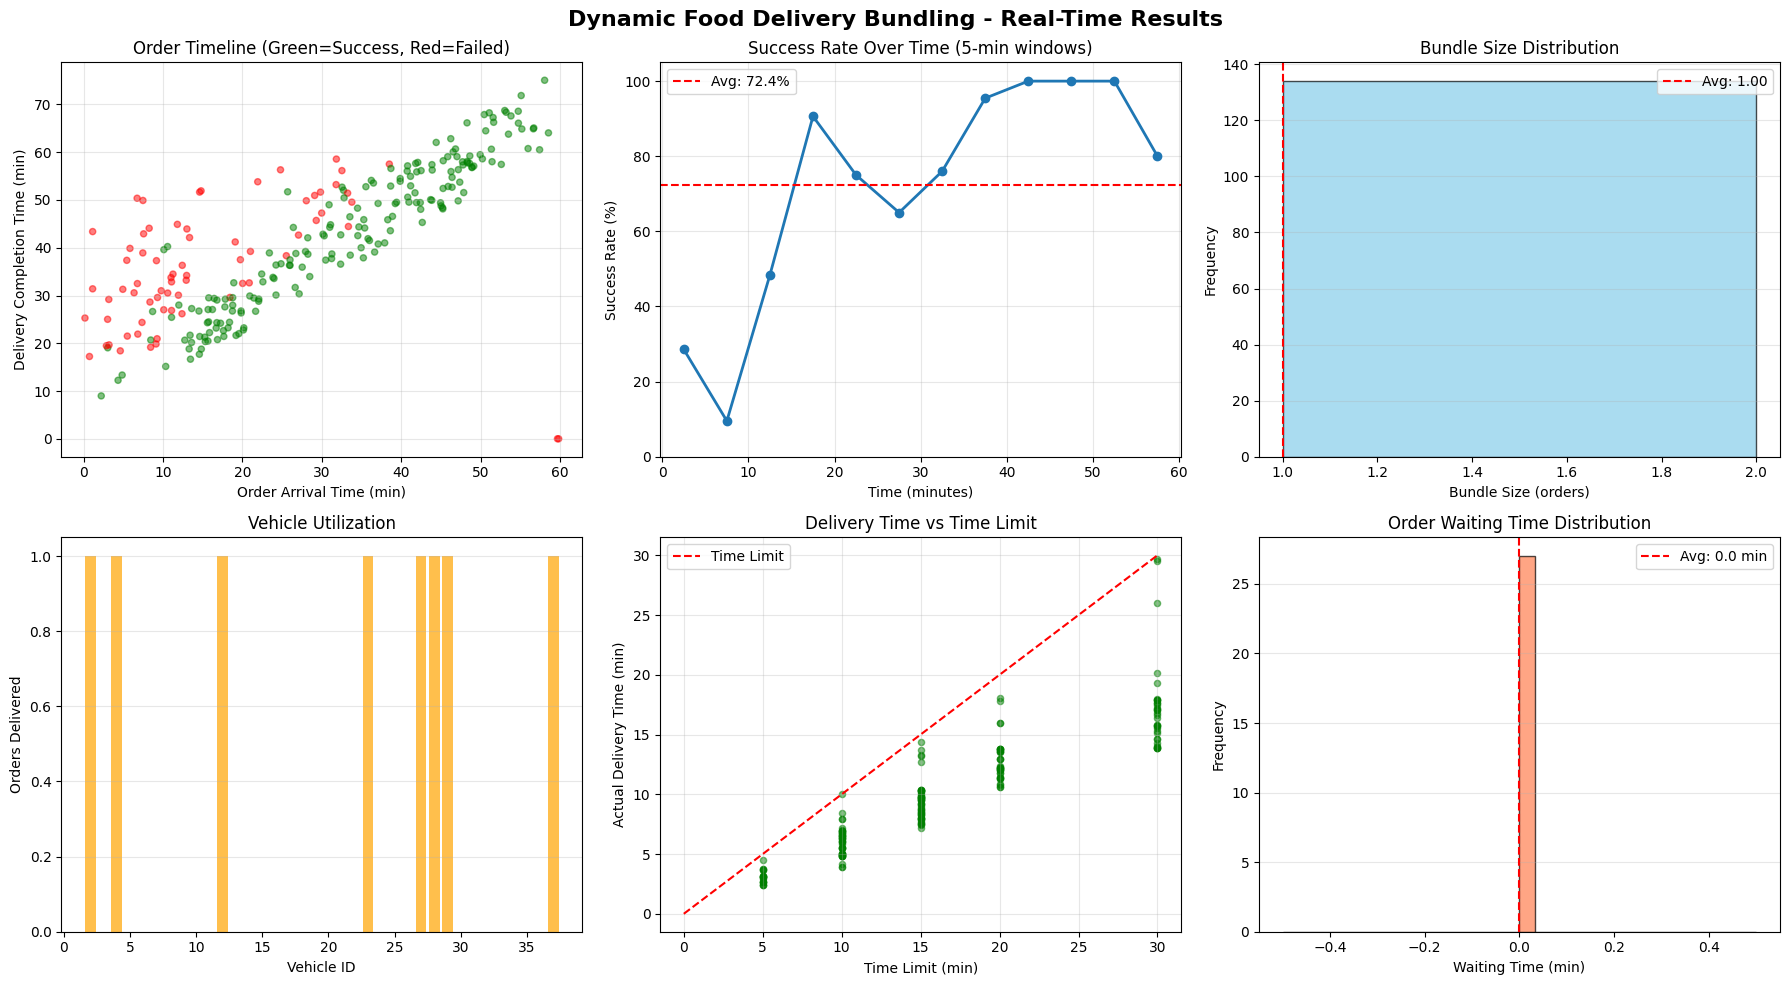

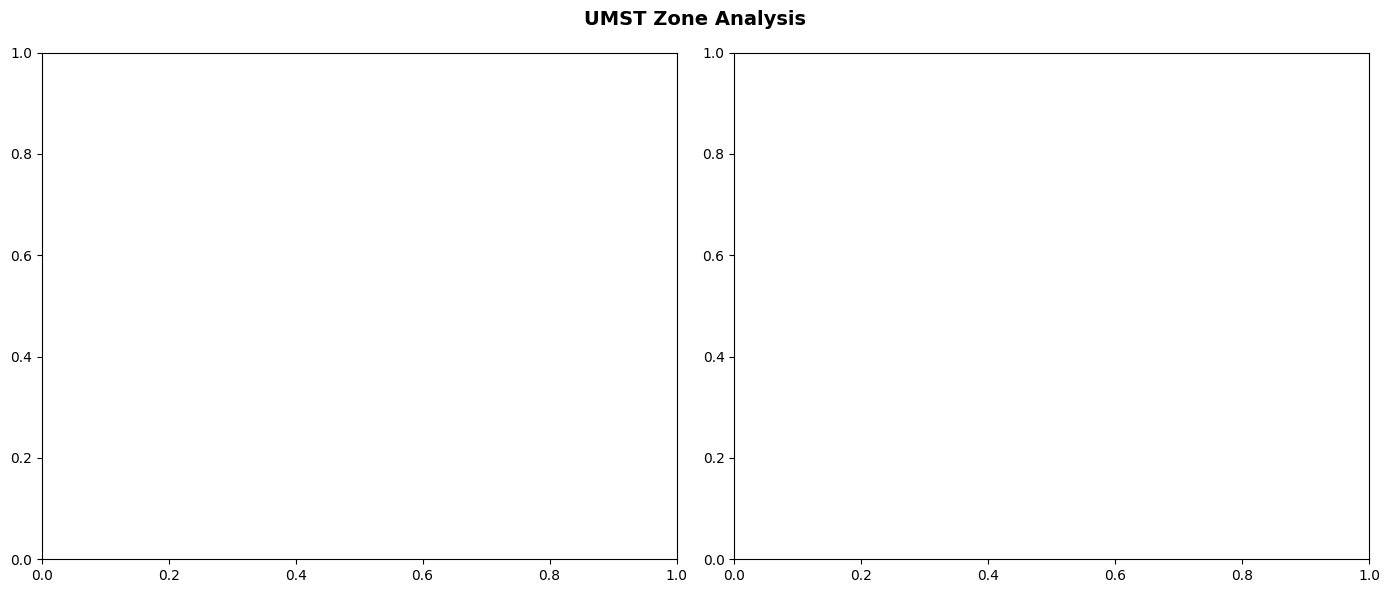


[8] Saving results...
✓ Simulation saved: dynamic_simulation.pkl
✓ Results JSON saved: dynamic_results.json
✓ Summary report saved: dynamic_summary.txt
✓ Matrices saved: matrices.pkl

✅ SIMULATION COMPLETE!

📊 Key Metrics:
Success Rate: 9.0%
Vehicles Used: 50
Total Distance: 314.75 km
Dynamic Insertions: 0


In [71]:
# ============================================================================
# AFTER YOUR GRAPH LOADING CODE, ADD THIS:
# ============================================================================

# YOUR EXISTING CODE LOADS THE GRAPHS
# Now run the dynamic simulation:

simulation_output = run_complete_dynamic_simulation(
    umst_graph=umst_graph,
    num_deliveries=300,
    max_bundle_size=1,
    time_window=300,        # 5 minutes
    simulation_hours=1,
    replan_interval=60,     # Replan every minute
    max_vehicles=50,
    distance_based="closer",
    save_files=True
)

# Access results
print(f"\n📊 Key Metrics:")
print(f"Success Rate: {simulation_output['results']['success_rate']*100:.1f}%")
print(f"Vehicles Used: {simulation_output['results']['vehicles_used']}")
print(f"Total Distance: {simulation_output['results']['total_distance_km']:.2f} km")
print(f"Dynamic Insertions: {simulation_output['results']['insertions']}")